# Restart File Output and Warm-Start Settings

This notebook validates the restart-file API split used by warm-start workflows:

1. Configure a copied plan to write a HEC-RAS restart file.
2. Run that plan through `RasCmdr.compute_plan()`.
3. Configure a copied unsteady-flow file and plan to use the generated restart file.
4. Run the warm-start continuation and compare hydraulic WSE time series against the continuous source run.
5. **Prove the restart file changed the initial state**: compare WSE at the first output timestep of the warm-start plan against both the cold-start IC and the source plan's state at the restart timestamp.
6. Confirm that restart output settings and restart usage settings still round-trip through the plan and unsteady-flow parsers.

In [1]:
# =============================================================================
# DEVELOPMENT MODE TOGGLE
# =============================================================================
from pathlib import Path
import os
import sys

USE_LOCAL_SOURCE = False

repo_root = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()
if USE_LOCAL_SOURCE:
    local_path = str(repo_root)
    if local_path not in sys.path:
        sys.path.insert(0, local_path)
    print(f"LOCAL SOURCE MODE: Loading from {local_path}/ras_commander")
else:
    print("PIP PACKAGE MODE: Loading installed ras-commander")

from datetime import datetime
from time import perf_counter
import logging

# Keep notebook output focused on API results instead of full ras-commander logs.
logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("numexpr").setLevel(logging.WARNING)
logging.disable(logging.INFO)
for logger_name in list(logging.root.manager.loggerDict):
    if logger_name.startswith("ras_commander"):
        logging.getLogger(logger_name).setLevel(logging.WARNING)

import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from shapely.geometry import LineString

from ras_commander import (
    GeomLateral,
    GeomStorage,
    HdfResultsXsec,
    HdfXsec,
    RasCmdr,
    RasExamples,
    RasPlan,
    RasUnsteady,
    init_ras_project,
    ras,
)
import ras_commander

for logger_name in list(logging.root.manager.loggerDict):
    if logger_name.startswith("ras_commander"):
        logging.getLogger(logger_name).setLevel(logging.WARNING)

plt.style.use("seaborn-v0_8-whitegrid")

print(f"Loaded ras-commander {ras_commander.__version__} from {ras_commander.__file__}")

PIP PACKAGE MODE: Loading installed ras-commander


Loaded ras-commander 0.96.2 from G:\GH\ras-commander-wt-501\ras_commander\__init__.py


## Parameters

The default artifact root uses a `working/notebook_runs` directory relative to the repository root. Set `RAS_COMMANDER_NOTEBOOK_WORKDIR` before execution to place generated projects somewhere else.

In [2]:
PROJECT_NAME = "Muncie"
RAS_VERSION = "7.0"
SOURCE_TEMPLATE_PLAN = "01"
RUN_SUFFIX = "restart_api"
NUM_CORES = 2

source_run_begin = datetime(1900, 1, 2, 0, 0)
source_run_end = datetime(1900, 1, 3, 0, 0)
restart_datetime = ("02JAN1900", "1200")
warm_start_begin = datetime(1900, 1, 2, 12, 0)
warm_start_end = source_run_end

artifact_root = Path(
    os.environ.get(
        "RAS_COMMANDER_NOTEBOOK_WORKDIR",
        str(repo_root / "working" / "notebook_runs"),
    )
)
artifact_root.mkdir(parents=True, exist_ok=True)

print(f"Artifact root: {artifact_root}")

Artifact root: G:\GH\ras-commander-wt-501\working\notebook_runs


## Extract and Initialize the Example Project

`RasExamples.extract_project()` gives the notebook a fresh project folder on each run, keeping the committed example assets immutable.

In [3]:
project_path = RasExamples.extract_project(
    PROJECT_NAME,
    output_path=artifact_root,
    suffix=RUN_SUFFIX,
)
init_ras_project(project_path, RAS_VERSION)

print(f"Project folder: {project_path}")
print(f"HEC-RAS executable: {ras.ras_exe_path}")

display_columns = [
    "plan_number",
    "unsteady_number",
    "Simulation Date",
    "Write IC File",
    "IC Time",
]
display(ras.plan_df[[c for c in display_columns if c in ras.plan_df.columns]])

unsteady_columns = [
    "unsteady_number",
    "Use Restart",
    "Restart Filename",
    "Use Fixed Start Time",
    "Fixed Start Date/Time",
]
display(ras.unsteady_df[[c for c in unsteady_columns if c in ras.unsteady_df.columns]])

Project folder: G:\GH\ras-commander-wt-501\working\notebook_runs\Muncie_restart_api
HEC-RAS executable: C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe


,plan_number,unsteady_number,Simulation Date,Write IC File,IC Time
0,01,01,"02JAN1900,0000,02JAN1900,2400",0,",,"
1,03,01,"02JAN1900,0000,02JAN1900,2400",0,",,"
2,04,01,"02JAN1900,0000,02JAN1900,2400",0,",,"


,unsteady_number,Use Restart,Restart Filename
0,01,0,Muncie.p05.02JAN1900 1200.rst


## Model Context and Reference-Point Strategy

The restart demonstration uses the Muncie source plan's base geometry. That plan is a 1D river and storage-area model, while other Muncie plans include 2D mesh alternatives that are not part of this restart workflow. The spatial context below identifies the elements an engineer needs before interpreting the hydrograph comparison: the White River cross sections, the storage areas that exchange flow, and the storage-area connections.

Because the p02/p05 restart workflow does not use a 2D mesh, the comparison uses a representative cross section as the reference point. The cross section is selected after the source run by finding the interior location with the largest source-run WSE range during the overlap window, then extracting the same location from the warm-start continuation.


,element,count,hydraulic_context
0,1D cross sections,61,Reference locations for channel WSE and flow r...
1,Storage areas,9,Floodplain storage volumes that exchange flow ...
2,Storage-area connections,10,Hydraulic links controlling exchange between s...
3,2D mesh cells in active restart plan,0,"The p02/p05 workflow uses g01, so cross sectio..."


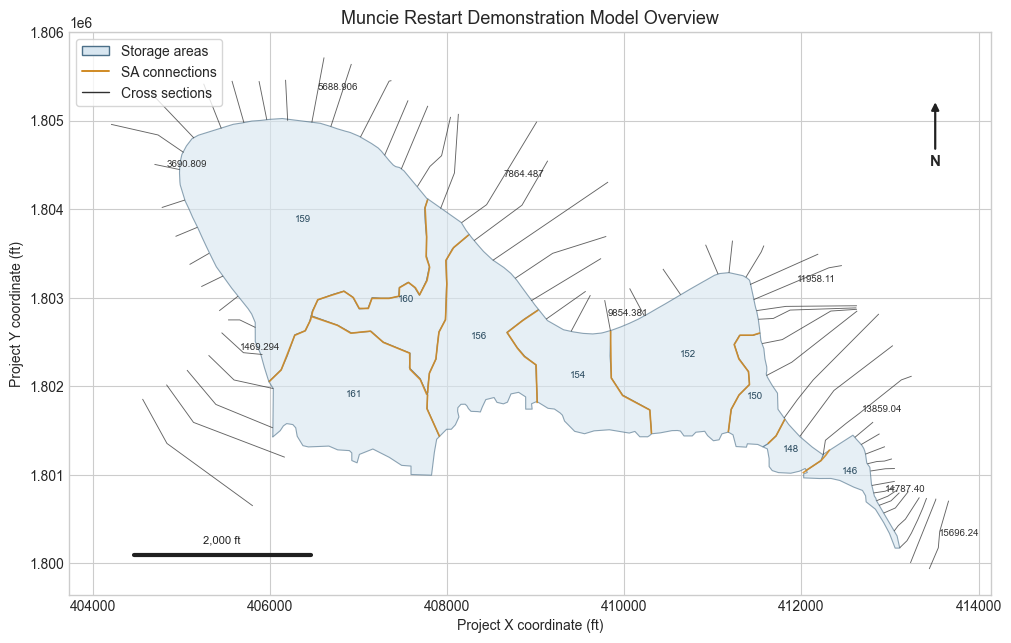

In [4]:
geom_file = project_path / f"{PROJECT_NAME}.g01"
geom_hdf_path = project_path / f"{PROJECT_NAME}.g01.hdf"

xsec_context_gdf = HdfXsec.get_cross_sections(geom_hdf_path)
storage_context_gdf = GeomStorage.get_storage_area_polygons(geom_file)
connection_context_df = GeomLateral.get_connections(geom_file)


def build_connection_gdf(geom_file, connection_df, crs=None):
    records = []
    for _, connection in connection_df.iterrows():
        try:
            coords = GeomLateral.get_connection_line_coords(geom_file, connection["Name"])
        except Exception:
            continue
        if len(coords) < 2:
            continue
        record = connection.to_dict()
        record["geometry"] = LineString(coords[["X", "Y"]].to_numpy())
        records.append(record)
    return gpd.GeoDataFrame(records, geometry="geometry", crs=crs)


connection_context_gdf = build_connection_gdf(
    geom_file,
    connection_context_df,
    crs=xsec_context_gdf.crs,
)

model_context = pd.DataFrame([
    {
        "element": "1D cross sections",
        "count": len(xsec_context_gdf),
        "hydraulic_context": "Reference locations for channel WSE and flow response",
    },
    {
        "element": "Storage areas",
        "count": len(storage_context_gdf),
        "hydraulic_context": "Floodplain storage volumes that exchange flow during the event",
    },
    {
        "element": "Storage-area connections",
        "count": len(connection_context_gdf),
        "hydraulic_context": "Hydraulic links controlling exchange between storage areas",
    },
    {
        "element": "2D mesh cells in active restart plan",
        "count": int(ras.geom_df.loc[ras.geom_df["geom_number"] == "01", "mesh_cell_count"].iloc[0]),
        "hydraulic_context": "The p02/p05 workflow uses g01, so cross sections are the valid reference points",
    },
])
display(model_context)


def add_north_arrow(ax):
    ax.annotate(
        "N",
        xy=(0.94, 0.88),
        xytext=(0.94, 0.77),
        xycoords="axes fraction",
        textcoords="axes fraction",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        arrowprops={"arrowstyle": "-|>", "lw": 1.6, "color": "#202020"},
    )


def add_scale_bar(ax, length_ft=None):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    dx = x1 - x0
    dy = y1 - y0
    if length_ft is None:
        target = abs(dx) * 0.18
        candidates = np.array([500, 1000, 2000, 5000, 10000], dtype=float)
        length_ft = float(candidates[np.argmin(np.abs(candidates - target))])
    start_x = x0 + dx * 0.07
    start_y = y0 + dy * 0.07
    ax.plot([start_x, start_x + length_ft], [start_y, start_y], color="#202020", linewidth=3)
    ax.text(
        start_x + length_ft / 2,
        start_y + dy * 0.018,
        f"{length_ft:,.0f} ft",
        ha="center",
        va="bottom",
        fontsize=8,
        color="#202020",
    )


def model_context_legend(include_selected=False):
    handles = [
        Patch(facecolor="#d8e6f0", edgecolor="#4b6f88", label="Storage areas"),
        Line2D([0], [0], color="#d08a24", lw=1.4, label="SA connections"),
        Line2D([0], [0], color="#303030", lw=1.0, label="Cross sections"),
    ]
    if include_selected:
        handles.append(Line2D([0], [0], color="#b3261e", lw=3.0, label="Selected reference XS"))
    return handles


def plot_model_context(ax, focus_bounds=None, selected_xsec=None):
    if not storage_context_gdf.empty:
        storage_context_gdf.plot(
            ax=ax,
            facecolor="#d8e6f0",
            edgecolor="#4b6f88",
            linewidth=0.8,
            alpha=0.62,
            label="Storage areas",
        )
    if not connection_context_gdf.empty:
        connection_context_gdf.plot(
            ax=ax,
            color="#d08a24",
            linewidth=1.2,
            alpha=0.9,
            label="SA connections",
        )
    if not xsec_context_gdf.empty:
        xsec_context_gdf.plot(
            ax=ax,
            color="#303030",
            linewidth=0.65,
            alpha=0.75,
            label="Cross sections",
        )
    if selected_xsec is not None and not selected_xsec.empty:
        selected_xsec.plot(
            ax=ax,
            color="#b3261e",
            linewidth=3.0,
            alpha=0.95,
            label="Selected reference XS",
        )
        row = selected_xsec.iloc[0]
        point = row.geometry.interpolate(0.5, normalized=True)
        ax.text(
            point.x,
            point.y,
            f"RS {row['RS']}",
            fontsize=9,
            fontweight="bold",
            color="#b3261e",
            ha="left",
            va="bottom",
            clip_on=True,
        )
    else:
        sample_step = max(1, len(xsec_context_gdf) // 8)
        for _, row in xsec_context_gdf.iloc[::sample_step].iterrows():
            point = row.geometry.interpolate(0.5, normalized=True)
            ax.text(point.x, point.y, str(row["RS"]), fontsize=7, color="#303030", clip_on=True)

    for _, row in storage_context_gdf.iterrows():
        center = row.geometry.centroid
        ax.text(center.x, center.y, str(row["Name"]), fontsize=7, color="#25465b", ha="center", clip_on=True)

    if focus_bounds is not None:
        minx, miny, maxx, maxy = focus_bounds
        width = maxx - minx
        height = maxy - miny
        buffer = max(width, height, 1200) * 0.65
        ax.set_xlim(minx - buffer, maxx + buffer)
        ax.set_ylim(miny - buffer, maxy + buffer)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Project X coordinate (ft)")
    ax.set_ylabel("Project Y coordinate (ft)")
    add_north_arrow(ax)
    add_scale_bar(ax)


fig, ax = plt.subplots(figsize=(10, 7.5), constrained_layout=True)
plot_model_context(ax)
ax.set_title("Muncie Restart Demonstration Model Overview", fontsize=13)
ax.legend(handles=model_context_legend(), loc="upper left", frameon=True)
plt.show()


## Configure Restart Output on a Copied Plan

`RasPlan.set_restart_output_settings()` writes the plan-file `Write IC File` block. This controls creation of restart files only; it does not turn on `Use Restart` in the unsteady-flow file.

In [5]:
source_plan = RasPlan.clone_plan(
    SOURCE_TEMPLATE_PLAN,
    new_shortid="RST_Source",
    new_title="Restart output source",
)

RasPlan.set_restart_output_settings(
    source_plan,
    save_datetime=restart_datetime,
    write_at_sim_end=False,
)

source_output_settings = RasPlan.get_restart_output_settings(source_plan)
restart_file = project_path / source_output_settings["expected_filename"]

print(f"Restart-output plan: p{source_plan}")
print(f"Expected restart file: {restart_file.name}")
display(pd.DataFrame([source_output_settings]).drop(columns=["raw", "compatibility_note"]))
display(pd.DataFrame([source_output_settings["raw"]]))

assert source_output_settings["enabled"] is True
assert source_output_settings["save_at_fixed_datetime"] is True
assert source_output_settings["save_datetime"] == "02JAN1900,1200"

Restart-output plan: p02
Expected restart file: Muncie.p02.02JAN1900 1200.rst


,enabled,save_at_fixed_datetime,save_time_hours,save_date,save_time,save_datetime,recurrence_interval_hours,write_at_sim_end,expected_filename,output_filename_pattern
0,True,True,None,02JAN1900,1200,"02JAN1900,1200",None,False,Muncie.p02.02JAN1900 1200.rst,ProjectName.p##.DDMMMYYYY hhmm.rst


,Write IC File,Write IC File at Fixed DateTime,IC Time,Write IC File Reoccurance,Write IC File at Sim End
0,1,-1,",02JAN1900,1200",,0


## Run the Restart-Output Source Plan

The plan is executed through `RasCmdr.compute_plan()`, which is the ras-commander API layer for HEC-RAS command-line execution.

In [6]:
start = perf_counter()
source_result = RasCmdr.compute_plan(
    source_plan,
    num_cores=NUM_CORES,
    verify=True,
    force_rerun=True,
)
source_seconds = perf_counter() - start

assert bool(source_result), "Restart-output source plan did not verify successfully"
assert restart_file.exists(), f"Expected restart file was not created: {restart_file}"

restart_file_info = pd.DataFrame([
    {
        "plan": source_plan,
        "restart_file": restart_file.name,
        "size_bytes": restart_file.stat().st_size,
        "runtime_seconds": round(source_seconds, 2),
    }
])
display(restart_file_info)

,plan,restart_file,size_bytes,runtime_seconds
0,02,Muncie.p02.02JAN1900 1200.rst,29396,11.94


## Configure a Warm-Start Plan to Use the Restart File

`RasUnsteady.set_restart_settings()` writes `Use Restart` and `Restart Filename` in a copied unsteady-flow file. The copied inline hydrograph is also pinned to the original event start with `RasUnsteady.set_hydrograph_fixed_start_time()` so the noon continuation receives the same boundary forcing that the full source run receives at noon. The continuation plan is then pointed at that unsteady-flow file and starts at the restart timestamp.

In [7]:
warm_unsteady = RasPlan.clone_unsteady(
    "01",
    new_title="Warm restart usage",
)
RasUnsteady.set_restart_settings(
    warm_unsteady,
    use_restart=True,
    restart_filename=restart_file.name,
)
boundary_timing_settings = RasUnsteady.set_hydrograph_fixed_start_time(
    warm_unsteady,
    use_fixed_start_time=True,
    fixed_start_datetime=source_run_begin,
)
warm_usage_settings = RasUnsteady.get_restart_settings(warm_unsteady)

warm_plan = RasPlan.clone_plan(
    source_plan,
    new_shortid="Warm_Start",
    new_title="Warm-start continuation",
    unsteady_flow=warm_unsteady,
)
RasPlan.update_simulation_date(
    warm_plan,
    warm_start_begin,
    warm_start_end,
)
RasPlan.set_restart_output_settings(warm_plan, enabled=False)

warm_output_settings = RasPlan.get_restart_output_settings(warm_plan)
warm_plan_date = RasPlan.get_plan_value(warm_plan, "Simulation Date")

print(f"Warm-start unsteady file: u{warm_unsteady}")
print(f"Warm-start plan: p{warm_plan}")
print(f"Warm-start simulation date: {warm_plan_date}")
display(pd.DataFrame([warm_usage_settings]).drop(columns=["raw", "compatibility_note"]))
display(pd.DataFrame([warm_usage_settings["raw"]]))
display(pd.DataFrame([boundary_timing_settings]).drop(columns=["unsteady_file"]))
display(pd.DataFrame([warm_output_settings]).drop(columns=["raw", "compatibility_note"]))

assert warm_usage_settings["use_restart"] is True
assert warm_usage_settings["restart_filename"] == restart_file.name
assert boundary_timing_settings["use_fixed_start_time"] is True
assert boundary_timing_settings["fixed_start_datetime"] == "02JAN1900,0000"
assert warm_output_settings["enabled"] is False
assert warm_plan_date == "02JAN1900,1200,03JAN1900,0000"

Warm-start unsteady file: u02
Warm-start plan: p05
Warm-start simulation date: 02JAN1900,1200,03JAN1900,0000


,use_restart,restart_filename
0,True,Muncie.p02.02JAN1900 1200.rst


,Use Restart,Restart Filename
0,-1,Muncie.p02.02JAN1900 1200.rst


,use_fixed_start_time,fixed_start_datetime,updated_use_fixed_start_time_lines,updated_fixed_start_datetime_lines,inserted_fixed_start_datetime_lines
0,True,"02JAN1900,0000",1,1,0


,enabled,save_at_fixed_datetime,save_time_hours,save_date,save_time,save_datetime,recurrence_interval_hours,write_at_sim_end,expected_filename,output_filename_pattern
0,False,False,None,None,None,None,None,False,None,ProjectName.p##.DDMMMYYYY hhmm.rst


## Run the Warm-Start Continuation

The warm-start run uses the restart file and solves only the second half of the event. The runtime summary compares the continuous source run against the continuation run and records the skipped spin-up period. The following section then compares actual hydraulic WSE time series in the shared time window.


In [8]:
start = perf_counter()
warm_result = RasCmdr.compute_plan(
    warm_plan,
    num_cores=NUM_CORES,
    verify=True,
    force_rerun=True,
)
warm_seconds = perf_counter() - start

assert bool(warm_result), "Warm-start continuation plan did not verify successfully"

summary = pd.DataFrame([
    {
        "workflow": "restart-output source",
        "plan": source_plan,
        "uses_restart_file": False,
        "hours_simulated": 24,
        "runtime_seconds": round(source_seconds, 2),
        "success": bool(source_result),
    },
    {
        "workflow": "warm-start continuation",
        "plan": warm_plan,
        "uses_restart_file": True,
        "hours_simulated": 12,
        "runtime_seconds": round(warm_seconds, 2),
        "success": bool(warm_result),
    },
])
summary["seconds_per_simulated_hour"] = (
    summary["runtime_seconds"] / summary["hours_simulated"]
).round(2)

spinup_hours_skipped = 12
runtime_delta_seconds = round(source_seconds - warm_seconds, 2)
print(f"Spin-up period skipped by restart workflow: {spinup_hours_skipped} hours")
print(f"Runtime difference observed on this workstation: {runtime_delta_seconds} seconds")
display(summary)

Spin-up period skipped by restart workflow: 12 hours
Runtime difference observed on this workstation: 2.92 seconds


,workflow,plan,uses_restart_file,hours_simulated,runtime_seconds,success,seconds_per_simulated_hour
0,restart-output source,02,False,24,11.94,True,0.50
1,warm-start continuation,05,True,12,9.02,True,0.75


## WSE Time Series Comparison

The source run and warm-start continuation are now compared at the same hydraulic reference point. The copied warm-start unsteady file keeps the source event hydrograph fixed at 02JAN1900 0000, so the continuation boundary forcing is aligned with the source run rather than replayed from the beginning at noon. The reference cross section is selected from the source run by the largest WSE range in the overlap window, with boundary-adjacent cross sections excluded, then the warm-start hydrograph is aligned to the source hydrograph over the common 12-hour window from 02JAN1900 1200 through 02JAN1900 2400.

This comparison is intentionally diagnostic. Small differences would support restart-file fidelity; large differences are reported as a restart-fidelity concern instead of being hidden behind the runtime comparison.


,reference_type,river,reach,station,name,selection_basis,overlap_wse_range_ft
0,1D cross section,White,Muncie,1743.103,,Largest source-run WSE range in overlap window...,2.984


,workflow,plan,max_wse_ft,time_to_peak,hours_from_plan_start,overlap_max_abs_difference_ft,overlap_rmse_ft,restart_fidelity_check
0,full source run,p02,939.443,1900-01-02 20:10:00,20.17,0.0001,0.0,acceptable small difference
1,warm-start continuation,p05,939.443,1900-01-02 20:10:00,8.17,0.0001,0.0,acceptable small difference


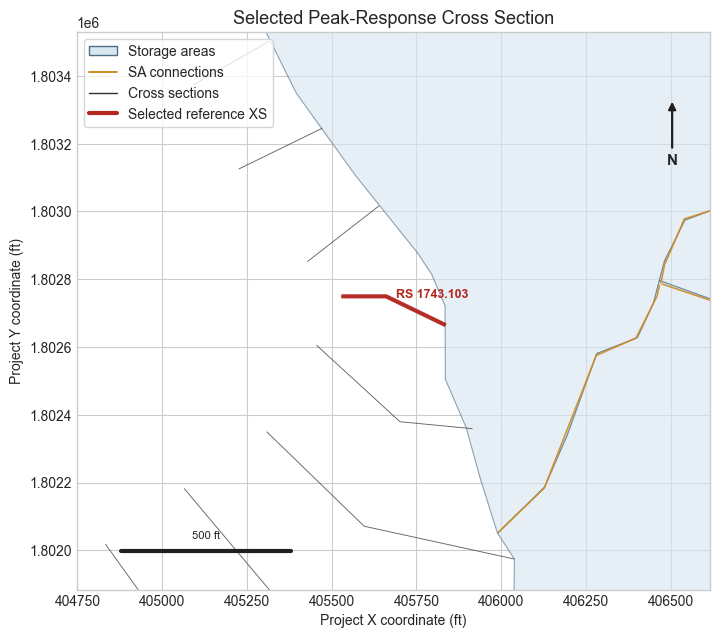

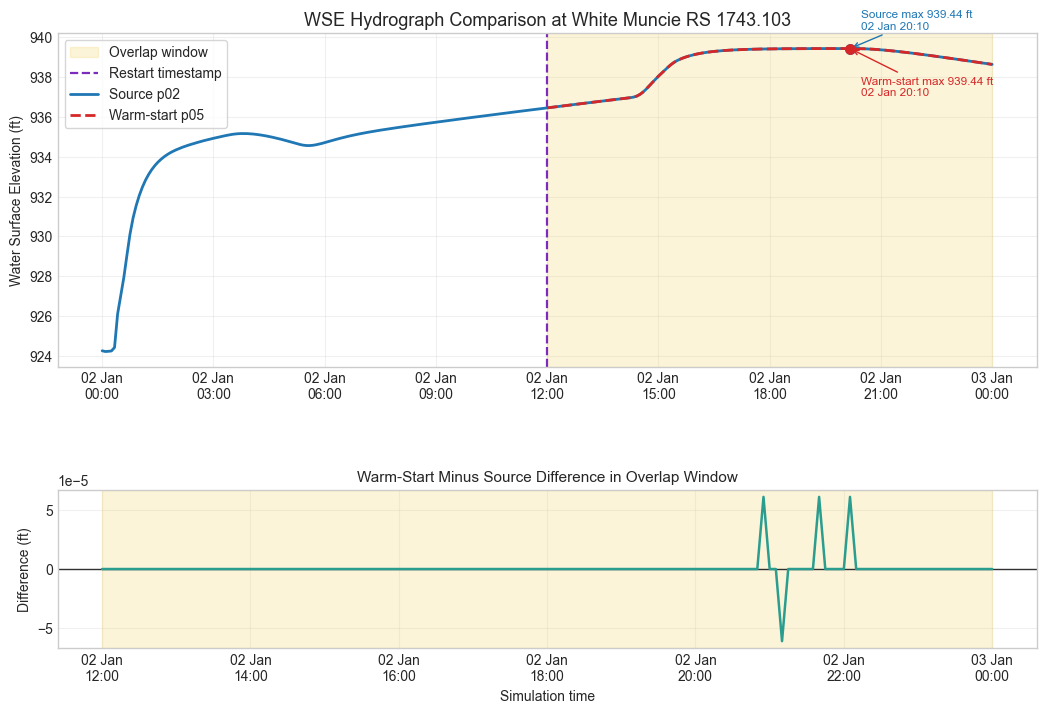

**Restart fidelity interpretation:** The comparison uses the interior cross section with the largest source-run WSE range in the overlap window and 145 aligned timesteps from 02Jan1900 12:00 through 03Jan1900 00:00. The maximum absolute difference is 0.0001 ft and RMSE is 0.0000 ft. The differences are small for an engineering restart check and indicate that the continuation is preserving the hydraulic state through the restart handoff. Small nonzero differences can occur because p05 is initialized from a saved restart state while sharing the same fixed-start boundary hydrograph clock as p02.

In [9]:
source_hdf_path = project_path / f"{PROJECT_NAME}.p{source_plan}.hdf"
warm_hdf_path = project_path / f"{PROJECT_NAME}.p{warm_plan}.hdf"

assert source_hdf_path.exists(), f"Source plan HDF not found: {source_hdf_path}"
assert warm_hdf_path.exists(), f"Warm-start plan HDF not found: {warm_hdf_path}"

source_xsec_ds = HdfResultsXsec.get_xsec_timeseries(source_hdf_path)
warm_xsec_ds = HdfResultsXsec.get_xsec_timeseries(warm_hdf_path)

restart_timestamp = pd.Timestamp(warm_start_begin)
overlap_start = restart_timestamp
overlap_end = pd.Timestamp(warm_start_end)

source_overlap_by_xs = source_xsec_ds["Water_Surface"].sel(time=slice(overlap_start, overlap_end))
source_wse_range_by_xs = source_overlap_by_xs.max(dim="time") - source_overlap_by_xs.min(dim="time")

trim_count = min(5, max(0, int(source_xsec_ds.sizes["cross_section"] * 0.1)))
candidate_indices = np.arange(source_xsec_ds.sizes["cross_section"])
if len(candidate_indices) > trim_count * 2:
    candidate_indices = candidate_indices[trim_count:-trim_count]

candidate_ranges = source_wse_range_by_xs.isel(cross_section=candidate_indices)
reference_xs_index = int(candidate_indices[int(candidate_ranges.argmax(dim="cross_section").item())])
reference_overlap_wse_range = float(source_wse_range_by_xs.isel(cross_section=reference_xs_index).item())
reference_station = str(source_xsec_ds["Station"].isel(cross_section=reference_xs_index).item()).strip()
reference_river = str(source_xsec_ds["River"].isel(cross_section=reference_xs_index).item()).strip()
reference_reach = str(source_xsec_ds["Reach"].isel(cross_section=reference_xs_index).item()).strip()
reference_name = str(source_xsec_ds["Name"].isel(cross_section=reference_xs_index).item()).strip()

warm_station_values = np.array([str(value).strip() for value in warm_xsec_ds["Station"].values])
warm_matches = np.flatnonzero(warm_station_values == reference_station)
warm_xs_index = int(warm_matches[0]) if len(warm_matches) else reference_xs_index

source_wse = source_xsec_ds["Water_Surface"].isel(cross_section=reference_xs_index).to_series()
warm_wse = warm_xsec_ds["Water_Surface"].isel(cross_section=warm_xs_index).to_series()
source_wse.index = pd.to_datetime(source_wse.index)
warm_wse.index = pd.to_datetime(warm_wse.index)
source_wse.name = "source_wse_ft"
warm_wse.name = "warm_start_wse_ft"

source_overlap = source_wse.loc[overlap_start:overlap_end]
warm_overlap = warm_wse.loc[overlap_start:overlap_end]
combined_index = source_overlap.index.union(warm_overlap.index).sort_values()
aligned_overlap = pd.DataFrame({
    "source_wse_ft": source_overlap.reindex(combined_index).interpolate(method="time"),
    "warm_start_wse_ft": warm_overlap.reindex(combined_index).interpolate(method="time"),
}).dropna()
aligned_overlap["difference_ft"] = aligned_overlap["warm_start_wse_ft"] - aligned_overlap["source_wse_ft"]

assert not aligned_overlap.empty, "No overlapping WSE timestamps found between source and warm-start runs"

max_abs_difference = float(aligned_overlap["difference_ft"].abs().max())
rmse_difference = float(np.sqrt(np.mean(np.square(aligned_overlap["difference_ft"]))))

def peak_summary(series, plan_start):
    peak_time = series.idxmax()
    return {
        "max_wse_ft": float(series.max()),
        "time_to_peak": peak_time,
        "hours_from_plan_start": round((peak_time - pd.Timestamp(plan_start)).total_seconds() / 3600, 2),
    }

source_peak = peak_summary(source_wse, source_run_begin)
warm_peak = peak_summary(warm_wse, warm_start_begin)

reference_point = pd.DataFrame([{
    "reference_type": "1D cross section",
    "river": reference_river,
    "reach": reference_reach,
    "station": reference_station,
    "name": reference_name or "",
    "selection_basis": "Largest source-run WSE range in overlap window among interior cross sections",
    "overlap_wse_range_ft": round(reference_overlap_wse_range, 3),
}])
display(reference_point)

comparison_stats = pd.DataFrame([
    {
        "workflow": "full source run",
        "plan": f"p{source_plan}",
        **source_peak,
        "overlap_max_abs_difference_ft": max_abs_difference,
        "overlap_rmse_ft": rmse_difference,
    },
    {
        "workflow": "warm-start continuation",
        "plan": f"p{warm_plan}",
        **warm_peak,
        "overlap_max_abs_difference_ft": max_abs_difference,
        "overlap_rmse_ft": rmse_difference,
    },
])
comparison_stats["max_wse_ft"] = comparison_stats["max_wse_ft"].round(3)
comparison_stats["overlap_max_abs_difference_ft"] = comparison_stats["overlap_max_abs_difference_ft"].round(4)
comparison_stats["overlap_rmse_ft"] = comparison_stats["overlap_rmse_ft"].round(4)
comparison_stats["restart_fidelity_check"] = (
    "acceptable small difference" if max_abs_difference <= 0.10 else "needs review: large difference"
)
display(comparison_stats)

selected_xsec_gdf = xsec_context_gdf[
    (xsec_context_gdf["River"].astype(str).str.strip() == reference_river)
    & (xsec_context_gdf["Reach"].astype(str).str.strip() == reference_reach)
    & (xsec_context_gdf["RS"].astype(str).str.strip() == reference_station)
]

if not selected_xsec_gdf.empty:
    fig, ax = plt.subplots(figsize=(9.0, 6.8))
    plot_model_context(ax, focus_bounds=selected_xsec_gdf.total_bounds, selected_xsec=selected_xsec_gdf)
    ax.set_title("Selected Peak-Response Cross Section", fontsize=13)
    ax.legend(handles=model_context_legend(include_selected=True), loc="upper left", frameon=True)
    fig.subplots_adjust(left=0.10, right=0.98, top=0.92, bottom=0.10)
    plt.show()

fig, (ax_wse, ax_diff) = plt.subplots(
    2,
    1,
    figsize=(11, 7.5),
    sharex=False,
    gridspec_kw={"height_ratios": [2.1, 1.0]},
)

ax_wse.axvspan(overlap_start, overlap_end, color="#f4d35e", alpha=0.24, label="Overlap window")
ax_wse.axvline(restart_timestamp, color="#7b2cbf", linestyle="--", linewidth=1.6, label="Restart timestamp")
ax_wse.plot(source_wse.index, source_wse.values, color="#1f77b4", linewidth=2.0, label=f"Source p{source_plan}")
ax_wse.plot(warm_wse.index, warm_wse.values, color="#d62728", linewidth=2.0, linestyle="--", label=f"Warm-start p{warm_plan}")

for label, series, peak, color in [
    ("Source", source_wse, source_peak, "#1f77b4"),
    ("Warm-start", warm_wse, warm_peak, "#d62728"),
]:
    peak_time = peak["time_to_peak"]
    peak_value = peak["max_wse_ft"]
    ax_wse.scatter([peak_time], [peak_value], color=color, s=46, zorder=5)
    ax_wse.annotate(
        f"{label} max {peak_value:.2f} ft\n{peak_time:%d %b %H:%M}",
        xy=(peak_time, peak_value),
        xytext=(8, 14 if label == "Source" else -34),
        textcoords="offset points",
        fontsize=8.5,
        color=color,
        arrowprops={"arrowstyle": "->", "color": color, "lw": 1.0},
    )

ax_wse.set_title(f"WSE Hydrograph Comparison at {reference_river} {reference_reach} RS {reference_station}", fontsize=13)
ax_wse.set_ylabel("Water Surface Elevation (ft)")
ax_wse.legend(loc="best", frameon=True)
ax_wse.grid(True, alpha=0.28)

ax_diff.axhline(0, color="#303030", linewidth=1.0)
ax_diff.axvspan(overlap_start, overlap_end, color="#f4d35e", alpha=0.24)
ax_diff.plot(aligned_overlap.index, aligned_overlap["difference_ft"], color="#2a9d8f", linewidth=1.8)
ax_diff.set_title("Warm-Start Minus Source Difference in Overlap Window", fontsize=11)
ax_diff.set_ylabel("Difference (ft)")
ax_diff.set_xlabel("Simulation time")
ax_diff.grid(True, alpha=0.28)

for ax in (ax_wse, ax_diff):
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M"))

fig.subplots_adjust(left=0.09, right=0.98, top=0.92, bottom=0.10, hspace=0.50)
plt.show()

if max_abs_difference <= 0.10:
    fidelity_note = "The differences are small for an engineering restart check and indicate that the continuation is preserving the hydraulic state through the restart handoff."
else:
    fidelity_note = "The differences are large enough that this run should not be treated as a fidelity-passing restart equivalence check without reviewing restart timing, output interval alignment, and model initialization behavior."

display(Markdown(
    f"**Restart fidelity interpretation:** The comparison uses the interior cross section with the largest source-run WSE range in the overlap window and {len(aligned_overlap)} aligned timesteps "
    f"from {overlap_start:%d%b%Y %H:%M} through {overlap_end:%d%b%Y %H:%M}. "
    f"The maximum absolute difference is {max_abs_difference:.4f} ft and RMSE is {rmse_difference:.4f} ft. "
    f"{fidelity_note} Small nonzero differences can occur because p05 is initialized from a saved restart state "
    f"while sharing the same fixed-start boundary hydrograph clock as p02."
))


## Initial-State Proof: Did the Restart File Actually Change the Hydraulic State?

The overlap comparison above shows the two runs converge, but convergence alone does not prove the restart file loaded. A model that ignores the restart file and starts from cold initial conditions could still converge to similar results once the boundary forcing dominates.

The definitive test reads WSE at the **first output timestep** of each plan:

| Quantity | What it shows |
|----------|---------------|
| Source plan at t=0 (cold start) | Base-flow WSE before the event — the default initial condition |
| Source plan at restart timestamp | Mid-event WSE when the restart file was written — the state the warm-start should inherit |
| Warm-start plan at t=0 | The hydraulic state the warm-start actually started from |

If the restart file loaded correctly, the warm-start t=0 WSE should match the source plan's WSE at the restart timestamp and be **visibly different** from the cold-start initial condition.

,quantity,plan,timestamp,wse_ft
0,Source plan t=0 (cold-start IC),p02,1900-01-02T00:00:00.000000,924.249
1,Source plan at restart timestamp,p02,1900-01-02 12:00:00,936.459
2,Warm-start plan t=0 (from restart file),p05,1900-01-02T12:00:00.000000,936.459


,comparison,mean_abs_diff_ft,max_abs_diff_ft,xs_count
0,Cold IC vs Source at restart (should be LARGE),8.7276,15.6941,61
1,Warm t=0 vs Source at restart (should be SMALL),0.0000,0.0000,61
2,Warm t=0 vs Cold IC (should be LARGE),8.7276,15.6941,61


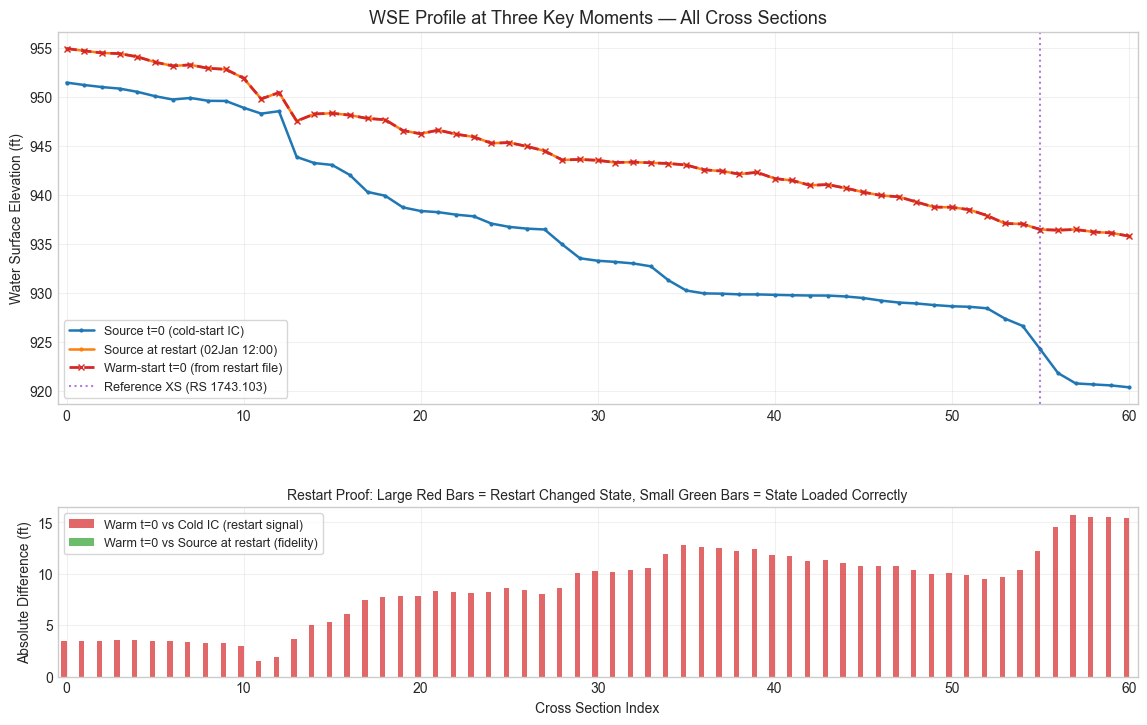

**Initial-state proof verdict: PASS**

The restart file changed the initial hydraulic state by 8.73 ft on average (warm t=0 differs from cold IC), and the loaded state matches the source run at the restart timestamp within 0.0000 ft on average.

In [10]:
# Read WSE profiles at key moments across ALL cross sections
cold_start_wse = source_xsec_ds["Water_Surface"].isel(time=0).values
source_at_restart = source_xsec_ds["Water_Surface"].sel(
    time=restart_timestamp, method="nearest"
).values
warm_start_t0_wse = warm_xsec_ds["Water_Surface"].isel(time=0).values

stations = np.array([str(s).strip() for s in source_xsec_ds["Station"].values])

# Build comparison at the reference cross section
proof_df = pd.DataFrame([
    {
        "quantity": f"Source plan t=0 (cold-start IC)",
        "plan": f"p{source_plan}",
        "timestamp": str(source_xsec_ds["time"].isel(time=0).values),
        "wse_ft": round(float(cold_start_wse[reference_xs_index]), 3),
    },
    {
        "quantity": f"Source plan at restart timestamp",
        "plan": f"p{source_plan}",
        "timestamp": str(restart_timestamp),
        "wse_ft": round(float(source_at_restart[reference_xs_index]), 3),
    },
    {
        "quantity": f"Warm-start plan t=0 (from restart file)",
        "plan": f"p{warm_plan}",
        "timestamp": str(warm_xsec_ds["time"].isel(time=0).values),
        "wse_ft": round(float(warm_start_t0_wse[warm_xs_index]), 3),
    },
])
display(proof_df)

# Quantify across ALL cross sections
cold_vs_restart = np.abs(source_at_restart - cold_start_wse)
warm_vs_restart = np.abs(warm_start_t0_wse - source_at_restart[:len(warm_start_t0_wse)])
warm_vs_cold = np.abs(warm_start_t0_wse - cold_start_wse[:len(warm_start_t0_wse)])

all_xs_summary = pd.DataFrame([
    {
        "comparison": "Cold IC vs Source at restart (should be LARGE)",
        "mean_abs_diff_ft": round(float(np.mean(cold_vs_restart)), 4),
        "max_abs_diff_ft": round(float(np.max(cold_vs_restart)), 4),
        "xs_count": len(cold_vs_restart),
    },
    {
        "comparison": "Warm t=0 vs Source at restart (should be SMALL)",
        "mean_abs_diff_ft": round(float(np.mean(warm_vs_restart)), 4),
        "max_abs_diff_ft": round(float(np.max(warm_vs_restart)), 4),
        "xs_count": len(warm_vs_restart),
    },
    {
        "comparison": "Warm t=0 vs Cold IC (should be LARGE)",
        "mean_abs_diff_ft": round(float(np.mean(warm_vs_cold)), 4),
        "max_abs_diff_ft": round(float(np.max(warm_vs_cold)), 4),
        "xs_count": len(warm_vs_cold),
    },
])
display(all_xs_summary)

# Plot the proof: WSE profile across all cross sections at these three moments
fig, (ax_profile, ax_diff) = plt.subplots(
    2, 1, figsize=(12, 7.5),
    gridspec_kw={"height_ratios": [2.2, 1.0]},
)

xs_positions = np.arange(len(stations))
ax_profile.plot(
    xs_positions, cold_start_wse, color="#1f77b4", linewidth=1.8,
    marker=".", markersize=4, label=f"Source t=0 (cold-start IC)",
)
ax_profile.plot(
    xs_positions, source_at_restart, color="#ff7f0e", linewidth=1.8,
    marker=".", markersize=4, label=f"Source at restart ({restart_timestamp:%d%b %H:%M})",
)
warm_xs_positions = np.arange(len(warm_start_t0_wse))
ax_profile.plot(
    warm_xs_positions, warm_start_t0_wse, color="#d62728", linewidth=2.0,
    linestyle="--", marker="x", markersize=5,
    label=f"Warm-start t=0 (from restart file)",
)
ax_profile.axvline(reference_xs_index, color="#7b2cbf", linestyle=":", alpha=0.6,
                   label=f"Reference XS (RS {reference_station})")
ax_profile.set_ylabel("Water Surface Elevation (ft)")
ax_profile.set_title("WSE Profile at Three Key Moments — All Cross Sections", fontsize=13)
ax_profile.legend(loc="best", frameon=True, fontsize=9)
ax_profile.grid(True, alpha=0.28)
ax_profile.set_xlim(-0.5, max(len(stations), len(warm_start_t0_wse)) - 0.5)

n_common = min(len(cold_start_wse), len(warm_start_t0_wse))
ax_diff.bar(
    np.arange(n_common) - 0.15, warm_vs_cold[:n_common], width=0.3,
    color="#d62728", alpha=0.7, label="Warm t=0 vs Cold IC (restart signal)",
)
ax_diff.bar(
    np.arange(n_common) + 0.15, warm_vs_restart[:n_common], width=0.3,
    color="#2ca02c", alpha=0.7, label="Warm t=0 vs Source at restart (fidelity)",
)
ax_diff.set_ylabel("Absolute Difference (ft)")
ax_diff.set_xlabel("Cross Section Index")
ax_diff.set_title("Restart Proof: Large Red Bars = Restart Changed State, Small Green Bars = State Loaded Correctly", fontsize=10)
ax_diff.legend(loc="best", frameon=True, fontsize=9)
ax_diff.grid(True, alpha=0.28)
ax_diff.set_xlim(-0.5, n_common - 0.5)

fig.subplots_adjust(left=0.08, right=0.98, top=0.94, bottom=0.08, hspace=0.38)
plt.show()

# Final verdict
restart_signal = float(np.mean(warm_vs_cold))
restart_fidelity = float(np.mean(warm_vs_restart))
if restart_signal > 0.5 and restart_fidelity < 0.5:
    verdict = "PASS"
    explanation = (
        f"The restart file changed the initial hydraulic state by {restart_signal:.2f} ft on average "
        f"(warm t=0 differs from cold IC), and the loaded state matches the source run at the restart "
        f"timestamp within {restart_fidelity:.4f} ft on average."
    )
elif restart_signal < 0.1:
    verdict = "INCONCLUSIVE"
    explanation = (
        f"The warm-start initial state is too similar to the cold-start IC "
        f"({restart_signal:.4f} ft mean difference) to confirm the restart file loaded. "
        f"This may indicate the restart timestamp is too early in the event."
    )
else:
    verdict = "NEEDS REVIEW"
    explanation = (
        f"The restart changed state ({restart_signal:.2f} ft from cold IC) but the loaded state "
        f"differs from the source at restart by {restart_fidelity:.2f} ft, which exceeds expected tolerance."
    )

display(Markdown(
    f"**Initial-state proof verdict: {verdict}**\n\n{explanation}"
))

## Round-Trip Parse Check

The final parse confirms that restart output creation remains in the plan file and restart usage remains in the unsteady-flow file.

In [11]:
ras.plan_df = ras.get_plan_entries()
ras.unsteady_df = ras.get_unsteady_entries()

round_trip = pd.DataFrame([
    {
        "file": f"p{source_plan}",
        "api": "RasPlan.get_restart_output_settings",
        "enabled": source_output_settings["enabled"],
        "save_datetime": source_output_settings["save_datetime"],
        "restart_filename": source_output_settings["expected_filename"],
    },
    {
        "file": f"u{warm_unsteady}",
        "api": "RasUnsteady.get_restart_settings",
        "enabled": warm_usage_settings["use_restart"],
        "save_datetime": None,
        "restart_filename": warm_usage_settings["restart_filename"],
    },
])

display(round_trip)

display(ras.plan_df[ras.plan_df["plan_number"].isin([source_plan, warm_plan])][[
    "plan_number",
    "unsteady_number",
    "Simulation Date",
    "Write IC File",
    "Write IC File at Fixed DateTime",
    "IC Time",
    "Write IC File Reoccurance",
    "Write IC File at Sim End",
]])

display(pd.DataFrame([boundary_timing_settings]).drop(columns=["unsteady_file"]))

unsteady_audit_columns = [
    "unsteady_number",
    "Use Restart",
    "Restart Filename",
    "Use Fixed Start Time",
    "Fixed Start Date/Time",
]
display(ras.unsteady_df[ras.unsteady_df["unsteady_number"].isin([warm_unsteady])][[
    column for column in unsteady_audit_columns if column in ras.unsteady_df.columns
]])

,file,api,enabled,save_datetime,restart_filename
0,p02,RasPlan.get_restart_output_settings,True,"02JAN1900,1200",Muncie.p02.02JAN1900 1200.rst
1,u02,RasUnsteady.get_restart_settings,True,NaN,Muncie.p02.02JAN1900 1200.rst


,plan_number,unsteady_number,Simulation Date,Write IC File,Write IC File at Fixed DateTime,IC Time,Write IC File Reoccurance,Write IC File at Sim End
3,02,01,"02JAN1900,0000,02JAN1900,2400",1,-1,",02JAN1900,1200",,0
4,05,02,"02JAN1900,1200,03JAN1900,0000",0,0,",,",,0


,use_fixed_start_time,fixed_start_datetime,updated_use_fixed_start_time_lines,updated_fixed_start_datetime_lines,inserted_fixed_start_datetime_lines
0,True,"02JAN1900,0000",1,1,0


,unsteady_number,Use Restart,Restart Filename
1,02,-1,Muncie.p02.02JAN1900 1200.rst
